In [2]:
import pandas as pd
import urllib.parse

# The correct URL with proper encoding
# The Cyrillic filename needs to be properly URL-encoded
filename = "модуль 3 - датасет - практика.csv"
encoded_filename = urllib.parse.quote(filename)
url = f"https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/{encoded_filename}"

print(f"Using URL: {url}")

# Load the data
df = pd.read_csv(url, nrows=5000)
print(f"Successfully loaded {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")

Using URL: https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv
Successfully loaded 5000 rows
Columns: ['subject_id', 'Count_subj', 'study_id', 'cart_id', 'Healthy_Status', 'eeg_time ', 'eeg_date ', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']


Available columns: ['subject_id', 'Count_subj', 'study_id', 'cart_id', 'Healthy_Status', 'eeg_time ', 'eeg_date ', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']

Required columns: ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']

Dataset shape: (5000, 9)
Missing values:
Count_subj        0
rr_interval       0
p_end             0
qrs_onset         0
qrs_end           0
p_axis            0
qrs_axis          0
t_axis            0
Healthy_Status    0
dtype: int64

Healthy_Status distribution:
Healthy_Status
0    4040
1     960
Name: count, dtype: int64
Percentage healthy: 19.2%

Features: ['Count_subj', 'rr_interval', 'p_end', '

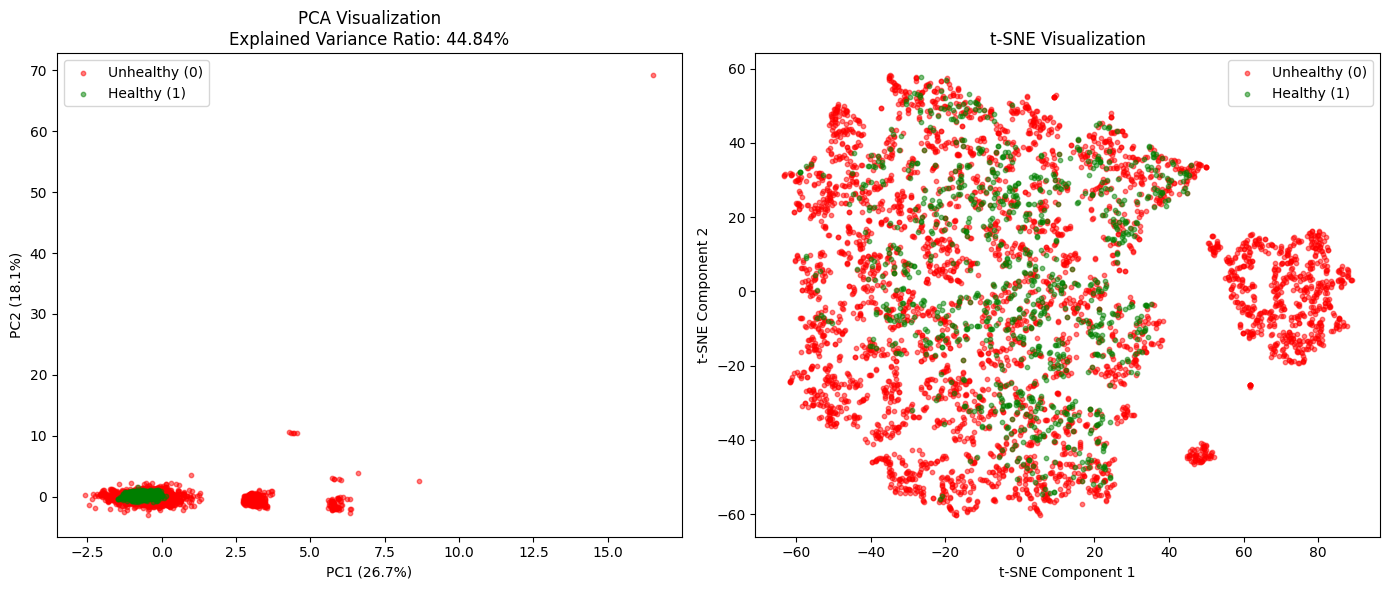


PCA explained variance ratio: [0.26692974 0.18146289]
Total variance explained by 2 components: 44.84%

Training set size: 4000
Test set size: 1000
Training class distribution: [3232  768]
Test class distribution: [808 192]

Random Forest:
  F1 Score: 0.5625
  Accuracy: 0.8460
  Precision: 0.6188
  Recall: 0.5156
  AUC-ROC: 0.9061

Gradient Boosting:
  F1 Score: 0.6098
  Accuracy: 0.8490
  Precision: 0.6051
  Recall: 0.6146
  AUC-ROC: 0.9084

Logistic Regression:
  F1 Score: 0.1416
  Accuracy: 0.8060
  Precision: 0.4706
  Recall: 0.0833
  AUC-ROC: 0.7978

BEST MODEL SELECTED: Gradient Boosting
F1 Score: 0.6098


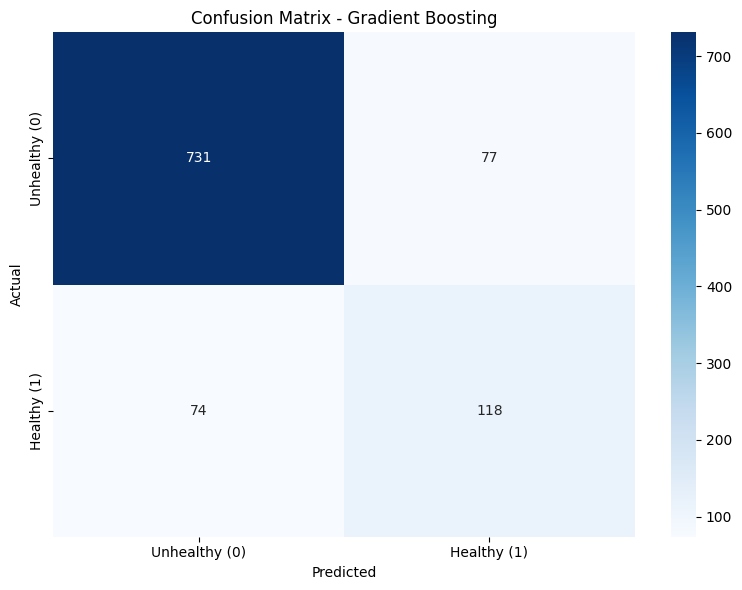


DETAILED CLASSIFICATION METRICS - Gradient Boosting

Confusion Matrix:
  True Positives (Healthy correctly identified): 118
  True Negatives (Unhealthy correctly identified): 731
  False Positives (Unhealthy misclassified as Healthy): 77
  False Negatives (Healthy misclassified as Unhealthy): 74

Performance Metrics:
  Accuracy:  0.8490 (84.90%)
  Precision: 0.6051 (60.51%)
  Recall:    0.6146 (61.46%)
  F1 Score:  0.6098 (60.98%)
  Specificity: 0.9047 (90.47%)
  NPV:       0.9081 (90.81%)
  AUC-ROC:   0.9084 (90.84%)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

Unhealthy (0)       0.91      0.90      0.91       808
  Healthy (1)       0.61      0.61      0.61       192

     accuracy                           0.85      1000
    macro avg       0.76      0.76      0.76      1000
 weighted avg       0.85      0.85      0.85      1000



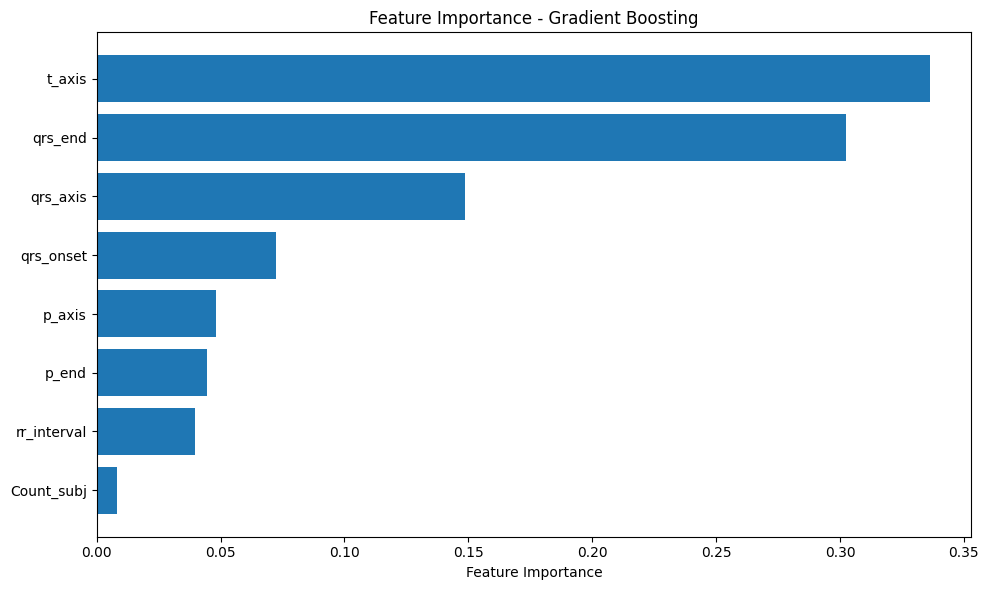


Feature Importance (Gradient Boosting):
  t_axis: 0.3362
  qrs_end: 0.3025
  qrs_axis: 0.1487
  qrs_onset: 0.0725
  p_axis: 0.0480
  p_end: 0.0445
  rr_interval: 0.0395
  Count_subj: 0.0080

SUMMARY REPORT

1. DATA PREPARATION:
   - Total rows loaded: 5000
   - Features used: 8
   - Target: Healthy_Status (binary classification)
   - Class distribution: Healthy=960, Unhealthy=4040

2. DIMENSIONALITY REDUCTION:
   - PCA: 2 components explain 44.84% of variance
   - t-SNE: 2D visualization created

3. MODEL COMPARISON:
   - Random Forest: F1 = 0.5625
   - Gradient Boosting: F1 = 0.6098
   - Logistic Regression: F1 = 0.1416

4. BEST MODEL: Gradient Boosting
   - F1 Score: 0.6098

5. FINAL PERFORMANCE ON TEST SET:
   - Accuracy:  84.90%
   - Precision: 60.51%
   - Recall:    61.46%
   - F1 Score:  60.98%

CONCLUSION:
The Gradient Boosting classifier achieved an F1 score of 0.6098 
for binary classification of patient health status based on ECG parameters.
The model correctly identifies 61

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. LOAD AND PREPARE DATA
# ============================================================================

# The data is already loaded from the GitHub URL
# Let's extract the required columns
required_columns = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 
                    'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']

# Check if all required columns exist
available_columns = df.columns.tolist()
print("Available columns:", available_columns)
print("\nRequired columns:", required_columns)

# Extract required columns
data = df[required_columns].copy()
print(f"\nDataset shape: {data.shape}")
print(f"Missing values:\n{data.isnull().sum()}")

# Handle missing values (replace 29999 which seems to be a placeholder for missing data)
# Based on the data preview, 29999 appears to be a missing value marker
for col in data.columns:
    if col != 'Healthy_Status':
        # Replace 29999 with NaN
        data[col] = data[col].replace(29999, np.nan)
        # Fill NaN with median
        data[col] = data[col].fillna(data[col].median())

# Check target distribution
print(f"\nHealthy_Status distribution:")
print(data['Healthy_Status'].value_counts())
print(f"Percentage healthy: {data['Healthy_Status'].mean()*100:.1f}%")

# ============================================================================
# 2. FEATURE ENGINEERING AND PREPROCESSING
# ============================================================================

# Separate features and target
X = data.drop('Healthy_Status', axis=1)
y = data['Healthy_Status']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures: {X.columns.tolist()}")
print(f"Feature statistics after scaling:")
print(pd.DataFrame(X_scaled, columns=X.columns).describe())

# ============================================================================
# 3. PCA AND t-SNE VISUALIZATION
# ============================================================================

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[y==0, 0], X_pca[y==0, 1], c='red', alpha=0.5, label='Unhealthy (0)', s=10)
axes[0].scatter(X_pca[y==1, 0], X_pca[y==1, 1], c='green', alpha=0.5, label='Healthy (1)', s=10)
axes[0].set_title(f'PCA Visualization\nExplained Variance Ratio: {pca.explained_variance_ratio_.sum():.2%}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend()

axes[1].scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], c='red', alpha=0.5, label='Unhealthy (0)', s=10)
axes[1].scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], c='green', alpha=0.5, label='Healthy (1)', s=10)
axes[1].set_title('t-SNE Visualization')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_tsne_visualization.png', dpi=150)
plt.show()

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# ============================================================================
# 4. TRAIN-TEST SPLIT
# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

# ============================================================================
# 5. MODEL TRAINING AND COMPARISON
# ============================================================================

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    results[name] = {
        'F1 Score': f1,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'AUC-ROC': auc,
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n{name}:")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    if auc:
        print(f"  AUC-ROC: {auc:.4f}")

# ============================================================================
# 6. SELECT BEST MODEL
# ============================================================================

# Select best model based on F1 score
best_model_name = max(results, key=lambda x: results[x]['F1 Score'])
best_results = results[best_model_name]

print(f"\n{'='*50}")
print(f"BEST MODEL SELECTED: {best_model_name}")
print(f"F1 Score: {best_results['F1 Score']:.4f}")
print(f"{'='*50}")

# ============================================================================
# 7. CONFUSION MATRIX
# ============================================================================

cm = confusion_matrix(y_test, best_results['y_pred'])

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Unhealthy (0)', 'Healthy (1)'],
            yticklabels=['Unhealthy (0)', 'Healthy (1)'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Extract confusion matrix values
tn, fp, fn, tp = cm.ravel()

# ============================================================================
# 8. ADDITIONAL METRICS
# ============================================================================

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

print(f"\n{'='*50}")
print(f"DETAILED CLASSIFICATION METRICS - {best_model_name}")
print(f"{'='*50}")
print(f"\nConfusion Matrix:")
print(f"  True Positives (Healthy correctly identified): {tp}")
print(f"  True Negatives (Unhealthy correctly identified): {tn}")
print(f"  False Positives (Unhealthy misclassified as Healthy): {fp}")
print(f"  False Negatives (Healthy misclassified as Unhealthy): {fn}")

print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {(tp + tn) / (tp + tn + fp + fn):.4f} ({((tp + tn) / (tp + tn + fp + fn))*100:.2f}%)")
print(f"  Precision: {best_results['Precision']:.4f} ({best_results['Precision']*100:.2f}%)")
print(f"  Recall:    {best_results['Recall']:.4f} ({best_results['Recall']*100:.2f}%)")
print(f"  F1 Score:  {best_results['F1 Score']:.4f} ({best_results['F1 Score']*100:.2f}%)")
print(f"  Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  NPV:       {npv:.4f} ({npv*100:.2f}%)")
if best_results['AUC-ROC']:
    print(f"  AUC-ROC:   {best_results['AUC-ROC']:.4f} ({best_results['AUC-ROC']*100:.2f}%)")

# ============================================================================
# 9. CLASSIFICATION REPORT
# ============================================================================

print(f"\n{'='*50}")
print("CLASSIFICATION REPORT")
print(f"{'='*50}")
print(classification_report(y_test, best_results['y_pred'], 
                           target_names=['Unhealthy (0)', 'Healthy (1)']))

# ============================================================================
# 10. FEATURE IMPORTANCE (for tree-based models)
# ============================================================================

if hasattr(best_results['model'], 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_results['model'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
    
    print(f"\nFeature Importance ({best_model_name}):")
    for _, row in feature_importance.iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")

# ============================================================================
# 11. SUMMARY
# ============================================================================

print(f"\n{'='*60}")
print("SUMMARY REPORT")
print(f"{'='*60}")

print("\n1. DATA PREPARATION:")
print(f"   - Total rows loaded: {len(data)}")
print(f"   - Features used: {len(X.columns)}")
print(f"   - Target: Healthy_Status (binary classification)")
print(f"   - Class distribution: Healthy={y.sum()}, Unhealthy={len(y)-y.sum()}")

print("\n2. DIMENSIONALITY REDUCTION:")
print(f"   - PCA: 2 components explain {pca.explained_variance_ratio_.sum():.2%} of variance")
print(f"   - t-SNE: 2D visualization created")

print("\n3. MODEL COMPARISON:")
for name, res in results.items():
    print(f"   - {name}: F1 = {res['F1 Score']:.4f}")

print(f"\n4. BEST MODEL: {best_model_name}")
print(f"   - F1 Score: {best_results['F1 Score']:.4f}")

print(f"\n5. FINAL PERFORMANCE ON TEST SET:")
print(f"   - Accuracy:  {best_results['Accuracy']*100:.2f}%")
print(f"   - Precision: {best_results['Precision']*100:.2f}%")
print(f"   - Recall:    {best_results['Recall']*100:.2f}%")
print(f"   - F1 Score:  {best_results['F1 Score']*100:.2f}%")

print(f"\n{'='*60}")
print("CONCLUSION:")
print(f"{'='*60}")
print(f"The {best_model_name} classifier achieved an F1 score of {best_results['F1 Score']:.4f} ")
print(f"for binary classification of patient health status based on ECG parameters.")
print(f"The model correctly identifies {best_results['Recall']*100:.1f}% of healthy patients ")
print(f"with {best_results['Precision']*100:.1f}% precision.")